# AIG4B — Clase 12
## Práctica: ECG, EEG y PPG — lo esencial

Tarea acompañante de la **Clase 12** (señales 1D biomédicas). Los datos vienen hechos; los **modelos los implementan ustedes** siguiendo las especificaciones del PDF de la clase.

Ejercicios:

- **1.1** — usar `neurokit2` para estimar bpm en ECG sintético.
- **1.2** — implementar la **toy CNN** de slide 21 y entrenarla para clasificar arritmias.
- **2.1** — implementar **EEGNet** siguiendo slide 29 para clasificar carga cognitiva.
- **3.1** — implementar un **mini-Transformer 1D** y verificar que resuelve la tarea de contexto largo donde una CNN falla.

Autores: Paulo Veiga y Marco Sanchez Sorondo · Mayo 2026

## Setup

La primera celda instala lo que falte (necesario en Colab).

In [1]:
import importlib, subprocess, sys
for pkg in ['wfdb', 'neurokit2']:
    try: importlib.import_module(pkg)
    except ImportError:
        print(f'instalando {pkg}...')
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', pkg])
print('listo')

instalando wfdb...
instalando neurokit2...
listo


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.signal as sps
import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset
import wfdb, neurokit2 as nk

np.random.seed(0); torch.manual_seed(0)
device = 'cuda' if torch.cuda.is_available() else 'cpu'
plt.rcParams['figure.figsize'] = (11, 3.5)
plt.rcParams['axes.grid'] = True
print(f'torch v{torch.__version__}  device={device}')

torch v2.12.0+cpu  device=cpu


## 1. ECG

**Idea central (slides 11, 14, 21):** un ECG es una secuencia de números + `fs`. La detección clásica de R-peaks es Pan-Tompkins; la versión AI usa CNNs. Para arritmias, una CNN simple ya supera lo que se podría hacer a mano con reglas R-R.

Cargamos un registro real de **MIT-BIH** (PhysioNet) y vemos cómo `neurokit2` lo procesa.

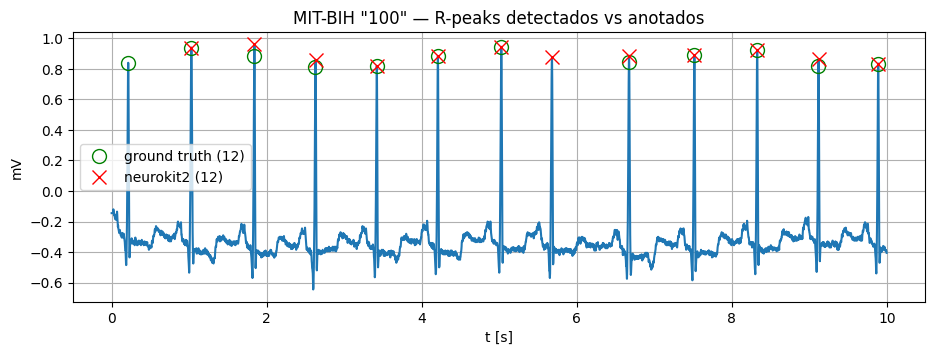

In [3]:
FS_ECG = 360
record = wfdb.rdrecord('100', pn_dir='mitdb', sampto=10*FS_ECG)
ecg_raw = record.p_signal[:, 0]
t_ecg = np.arange(len(ecg_raw)) / FS_ECG

ann = wfdb.rdann('100', 'atr', pn_dir='mitdb', sampto=10*FS_ECG)
r_gt = np.array([s for s, sym in zip(ann.sample, ann.symbol) if sym == 'N'])

_, info = nk.ecg_peaks(ecg_raw, sampling_rate=FS_ECG)
r_nk = info['ECG_R_Peaks']

plt.plot(t_ecg, ecg_raw)
plt.plot(t_ecg[r_gt], ecg_raw[r_gt], 'go', ms=10, mfc='none', label=f'ground truth ({len(r_gt)})')
plt.plot(t_ecg[r_nk], ecg_raw[r_nk], 'rx', ms=10, label=f'neurokit2 ({len(r_nk)})')
plt.xlabel('t [s]'); plt.ylabel('mV'); plt.legend()
plt.title('MIT-BIH "100" — R-peaks detectados vs anotados')
plt.show()

### Helper · generador de ECG sintético

Función provista para los ejercicios. **No es parte del ejercicio**, solo úsenla.

In [4]:
def synthetic_ecg(duration_s, fs, hr_bpm):
    """ECG sintético: suma de gaussianas P-Q-R-S-T repetidas a hr_bpm."""
    t = np.arange(0, duration_s, 1/fs); rr = 60.0/hr_bpm
    ecg = np.zeros_like(t)
    waves = [(0.00,0.025,0.15),(0.15,0.010,-0.10),(0.17,0.008,1.20),(0.19,0.010,-0.25),(0.35,0.04,0.35)]
    for k in range(int(duration_s/rr)+1):
        t0 = k * rr
        for off, sigma, amp in waves:
            ecg += amp * np.exp(-((t-t0-off)**2)/(2*sigma**2))
    return t, ecg

### Ejercicio 1.1 — estimar bpm con `neurokit2`

1. Generá un ECG sintético de 30 s con frecuencia cardíaca aleatoria entre 50 y 110 bpm (sin imprimir cuál).
2. Usá `nk.ecg_peaks` para detectar los R-peaks.
3. Estimá la frecuencia cardíaca a partir de los intervalos R-R y comparala con el valor real.

BPM estimados: 94.00
BPM reales: 94
Error absoluto: 0.00 bpm


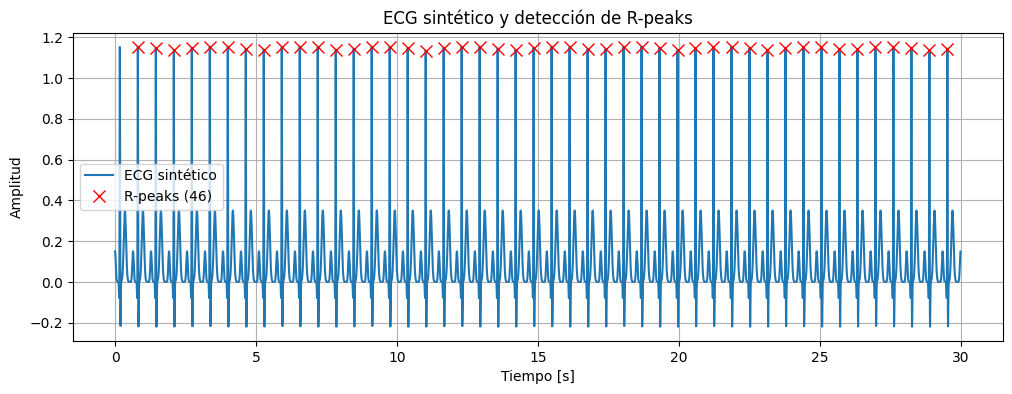

In [5]:
FS_ECG = 360
DURATION = 30  # segs

hr_real = np.random.randint(50, 111)  # random entre 50 y 110 bpm

t_ecg, ecg_raw = synthetic_ecg(duration_s=DURATION, fs=FS_ECG, hr_bpm=hr_real)


_, info = nk.ecg_peaks(ecg_raw, sampling_rate=FS_ECG)

r_peaks = info["ECG_R_Peaks"]

# Intervalos RR en muestras
rr_samples = np.diff(r_peaks)

# Pasamos a segundos
rr_seconds = rr_samples / FS_ECG

# RR promedio
rr_mean = np.mean(rr_seconds)

# BPM estimados
hr_estimada = 60 / rr_mean

print(f"BPM estimados: {hr_estimada:.2f}")
print(f"BPM reales: {hr_real}")
print(f"Error absoluto: {abs(hr_real - hr_estimada):.2f} bpm")

plt.figure(figsize=(12,4))
plt.plot(t_ecg, ecg_raw, label="ECG sintético")
plt.plot(
    t_ecg[r_peaks],
    ecg_raw[r_peaks],
    "rx",
    ms=8,
    label=f"R-peaks ({len(r_peaks)})"
)

plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud")
plt.title("ECG sintético y detección de R-peaks")
plt.legend()
plt.grid(True)
plt.show()



### Dataset de arritmias (provisto)

Tres clases (slide 13): **normal** (RR regular), **AFIB** (RR aleatorio + morfología sucia), **bigeminismo** (RR alternante corto-largo). El dataset y el split train/val vienen hechos; ustedes se ocupan del modelo.

Train: (720, 500)  Val: (180, 500)  Clases: ['normal', 'AFIB', 'bigeminismo']


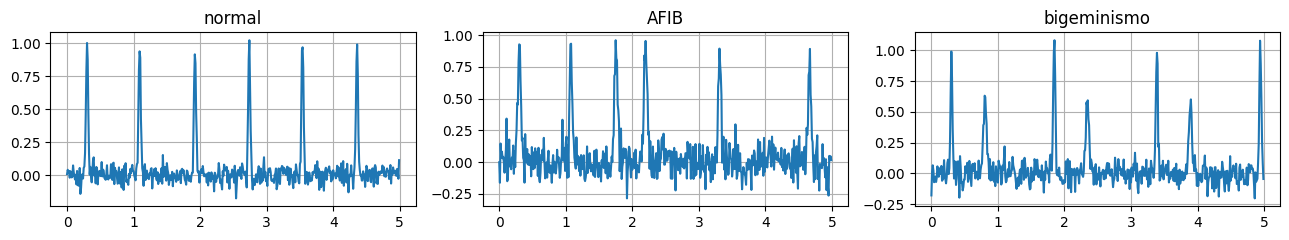

In [6]:
FS = 100; WIN = 500  # 5 s a 100 Hz

def make_rr_window(label, rng):
    t = np.arange(WIN) / FS
    sig = np.zeros(WIN, dtype=np.float32)
    if label == 0:
        hr = rng.uniform(60, 80)
        rrs = np.full(15, 60/hr) + rng.normal(0, 0.02, 15)
        amps, widths, noise = np.full(15, 1.0), np.full(15, 0.015), 0.05
    elif label == 1:
        rrs = rng.uniform(0.4, 1.4, 15)
        amps = np.full(15, 0.9) + rng.normal(0, 0.10, 15)
        widths = rng.uniform(0.018, 0.025, 15); noise = 0.10
    else:
        s = rng.uniform(0.45, 0.55); l = rng.uniform(1.05, 1.20)
        rrs = np.array([s, l] * 8)[:15] + rng.normal(0, 0.02, 15)
        amps = np.array([1.0, 0.6] * 8)[:15]
        widths = np.array([0.015, 0.025] * 8)[:15]; noise = 0.07
    t_pos = 0.3
    for rr, amp, w in zip(rrs, amps, widths):
        if t_pos >= WIN / FS: break
        sig += amp * np.exp(-((t - t_pos) ** 2) / (2 * w ** 2))
        t_pos += rr
    return sig + noise * rng.standard_normal(WIN).astype(np.float32)

rng = np.random.default_rng(0); n_per = 300
labels_arr = ['normal', 'AFIB', 'bigeminismo']
X = np.stack([make_rr_window(c, rng) for c in [0]*n_per + [1]*n_per + [2]*n_per])
y = np.array([0]*n_per + [1]*n_per + [2]*n_per, dtype=np.int64)
idx = rng.permutation(len(X)); X, y = X[idx], y[idx]
split = int(0.8*len(X))
X_tr, X_va, y_tr, y_va = X[:split], X[split:], y[:split], y[split:]
print(f'Train: {X_tr.shape}  Val: {X_va.shape}  Clases: {labels_arr}')

fig, axes = plt.subplots(1, 3, figsize=(13, 2.5))
for ax, c in zip(axes, [0, 1, 2]):
    ax.plot(np.arange(WIN)/FS, X[y == c][0])
    ax.set_title(labels_arr[c])
plt.tight_layout(); plt.show()

### Ejercicio 1.2 — implementar y entrenar la toy CNN (slide 21)

Implementá **exactamente** la arquitectura de la slide 21 y entrenala sobre el dataset de arritmias.

**Arquitectura:**
```
Conv1D(in=1, out=16, kernel_size=5)  →  ReLU  →  MaxPool1D(kernel=2)
Conv1D(in=16, out=32, kernel_size=5) →  ReLU
GlobalAvgPool1D  →  Flatten  →  Linear(32, 3)
```

**Entrenamiento:** 15 epochs, optimizer Adam (lr=1e-3), loss `CrossEntropyLoss`, batch size 32.

**Reportar:**
- `val_acc` final
- matriz de confusión 3×3
- **sensibilidad** (recall) y **especificidad** por clase (las dos métricas clínicas clave)

*Pista para GlobalAvgPool1D:* en PyTorch se logra con `nn.AdaptiveAvgPool1d(1)` seguido de `nn.Flatten()`.

Usando: cpu
Epoch 01/15 | loss=1.0991 | val_acc=0.2833
Epoch 02/15 | loss=1.0965 | val_acc=0.2833
Epoch 03/15 | loss=1.0923 | val_acc=0.6500
Epoch 04/15 | loss=1.0869 | val_acc=0.6500
Epoch 05/15 | loss=1.0804 | val_acc=0.6500
Epoch 06/15 | loss=1.0675 | val_acc=0.6500
Epoch 07/15 | loss=1.0508 | val_acc=0.6500
Epoch 08/15 | loss=1.0275 | val_acc=0.6500
Epoch 09/15 | loss=0.9948 | val_acc=0.6500
Epoch 10/15 | loss=0.9545 | val_acc=0.7722
Epoch 11/15 | loss=0.9004 | val_acc=0.7444
Epoch 12/15 | loss=0.8412 | val_acc=0.8944
Epoch 13/15 | loss=0.7835 | val_acc=0.7389
Epoch 14/15 | loss=0.7198 | val_acc=0.9944
Epoch 15/15 | loss=0.6625 | val_acc=0.9889

VAL_ACC FINAL: 0.9889

MATRIZ DE CONFUSIÓN:
[[51  0  0]
 [ 0 66  0]
 [ 1  1 61]]


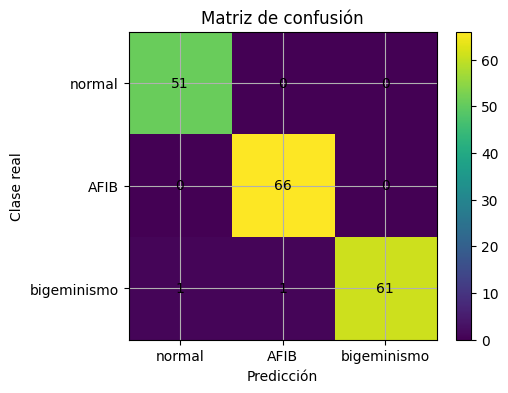


MÉTRICAS POR CLASE

Clase: normal
Sensibilidad (Recall): 1.0000
Especificidad:         0.9922

Clase: AFIB
Sensibilidad (Recall): 1.0000
Especificidad:         0.9912

Clase: bigeminismo
Sensibilidad (Recall): 0.9683
Especificidad:         1.0000


In [7]:
from sklearn.metrics import confusion_matrix

# Agregamos dimensión de canal: (N, 500) -> (N, 1, 500)
X_tr_torch = torch.tensor(X_tr, dtype=torch.float32).unsqueeze(1)
X_va_torch = torch.tensor(X_va, dtype=torch.float32).unsqueeze(1)

y_tr_torch = torch.tensor(y_tr, dtype=torch.long)
y_va_torch = torch.tensor(y_va, dtype=torch.long)

# Datasets
train_ds = TensorDataset(X_tr_torch, y_tr_torch)
val_ds = TensorDataset(X_va_torch, y_va_torch)

# DataLoaders
train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)

val_loader = DataLoader(val_ds, batch_size=32, shuffle=False)

class ToyCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Conv1d(
                in_channels=1,
                out_channels=16,
                kernel_size=5
            ),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2),
            nn.Conv1d(
                in_channels=16,
                out_channels=32,
                kernel_size=5
            ),
            nn.ReLU(),
            nn.AdaptiveAvgPool1d(1),
            nn.Flatten(),
            nn.Linear(32, 3)
        )

    def forward(self, x):
        return self.model(x)

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Usando:", device)

model = ToyCNN().to(device)

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-3
)


n_epochs = 15

train_losses = []
val_accs = []

for epoch in range(n_epochs):

    model.train()
    running_loss = 0
    for x_batch, y_batch in train_loader:

        x_batch = x_batch.to(device)
        y_batch = y_batch.to(device)

        # Forward
        y_pred = model(x_batch)
        loss = criterion(y_pred, y_batch)

        # Backprop
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    epoch_loss = running_loss / len(train_loader)
    train_losses.append(epoch_loss)


    model.eval()

    correct = 0
    total = 0

    with torch.no_grad():

        for x_batch, y_batch in val_loader:

            x_batch = x_batch.to(device)
            y_batch = y_batch.to(device)

            outputs = model(x_batch)

            preds = torch.argmax(outputs, dim=1)

            correct += (preds == y_batch).sum().item()
            total += y_batch.size(0)

    val_acc = correct / total
    val_accs.append(val_acc)

    print(
        f"Epoch {epoch+1:02d}/{n_epochs} | "
        f"loss={epoch_loss:.4f} | "
        f"val_acc={val_acc:.4f}"
    )


model.eval()

y_true = []
y_pred = []

with torch.no_grad():

    for x_batch, y_batch in val_loader:

        x_batch = x_batch.to(device)

        outputs = model(x_batch)

        preds = torch.argmax(outputs, dim=1)

        y_true.extend(y_batch.numpy())
        y_pred.extend(preds.cpu().numpy())

y_true = np.array(y_true)
y_pred = np.array(y_pred)



val_acc_final = np.mean(y_true == y_pred)

print("\n" + "="*50)
print(f"VAL_ACC FINAL: {val_acc_final:.4f}")


cm = confusion_matrix(y_true, y_pred)

print("\nMATRIZ DE CONFUSIÓN:")
print(cm)


plt.figure(figsize=(5,4))
plt.imshow(cm)
plt.colorbar()

plt.xticks(
    range(3),
    labels_arr
)

plt.yticks(
    range(3),
    labels_arr
)

plt.xlabel("Predicción")
plt.ylabel("Clase real")
plt.title("Matriz de confusión")

for i in range(3):
    for j in range(3):
        plt.text(
            j,
            i,
            cm[i, j],
            ha="center",
            va="center"
        )

plt.show()



print("\nMÉTRICAS POR CLASE")

for i, clase in enumerate(labels_arr):

    TP = cm[i, i]

    FN = cm[i, :].sum() - TP

    FP = cm[:, i].sum() - TP

    TN = cm.sum() - TP - FN - FP

    # Sensibilidad (Recall)
    sensibilidad = TP / (TP + FN)

    # Especificidad
    especificidad = TN / (TN + FP)

    print(f"\nClase: {clase}")
    print(f"Sensibilidad (Recall): {sensibilidad:.4f}")
    print(f"Especificidad:         {especificidad:.4f}")

### Preguntas conceptuales — toy CNN (Ej 1.2)

Justificá brevemente cada decisión de la arquitectura y del entrenamiento. Una o dos oraciones por pregunta.

1. ¿Por qué usamos `Conv1D` en vez de `Linear` para procesar la señal?
2. `kernel_size=5` a `fs=100 Hz`: ¿cuántos milisegundos cubre el kernel? ¿Por qué ese tamaño tiene sentido para un ECG?
3. ¿Para qué sirve `MaxPool1d(2)`?
4. ¿Por qué la segunda Conv1D pasa de 16 a 32 filtros (el número crece al profundizar)?
5. ¿Qué hace `AdaptiveAvgPool1d(1)`? ¿Qué se gana y qué se pierde al colapsar toda la dimensión temporal?
6. ¿Por qué la última capa `Linear` tiene **3** outputs y no hay activación softmax después?
7. ¿Por qué `CrossEntropyLoss` es la loss apropiada y por qué usamos `Adam` y no `SGD`?

#### Respuesta
1. Usamos Conv1D porque recorre la señal temporal (ECG) pequeñas ventanas (kernels), lo que nos permite detectar patrones como picos R. Una capa Linear trataría cada punto de la señal de manera independiente y perdería la información temporal y de las muestras vecinas.

2. Como fs=100Hz, tengo que cada sample representa 1/100=0.01s, entonces un kernel de 5 cubre 0.05s=50ms. Este tamaño tiene sentido porque los eventos importantes ocurren en escalas cortas de tiempo.

3. MaxPool1d(2) reduce cantidad de datos conservando las activaciones más importantes. Esto ayuda a disminuir el costo computacional(porque baja la dimensión), reducir el ruido y se comporta mejor frente a pequeños desplazamientos de los picos.

4. En las primeras capas, la red aprende características simples de la señal (picos o cambios bruscos). A medida que la red profundiza, necesita combinar esas características para reconocer patrones más complejos, (irregularidades del ritmo o alternancia de latidos), por eso aumenta el número de filtros.

5. AdaptiveAvgPool1d(1) hace un promedio  de cada filtro y deja un solo valor por canal. Se gana una representación compacta y con menos parámetros para entrenar; sin embargo, se pierde información exacta sobre cuándo ocurrió cada evento dentro de la señal.

6. La última capa Linear tiene 3 salidas porque el problema tiene tres clases (normal, AFIB y bigeminismo). No se agrega una capa softmax (convierte a prob) porque CrossEntropyLoss ya la aplica.

7. CrossEntropyLoss es la Loss apropiada porque estamos en un problema de clasificación multiclase. Se usa Adam en lugar de SGD porque ajusta automáticamente el tamaño de los pasos de aprendizaje para cada parámetro y es menos sensible al lr.

## 2. EEG

**Idea central (slides 25, 27, 29):** EEG es una **matriz** `[canales × tiempo]`, no un vector. **EEGNet** (Lawhern 2018) es el baseline estándar. Lo implementamos siguiendo la slide 29 del PDF.

Dataset sintético con bandas EEG realistas: carga cognitiva **baja** (predominio α) vs **alta** (predominio β).

In [8]:
FS_EEG = 128; N_CHANS = 14; N_SAMPLES = 128  # 1 segundo
BANDS = {'delta':(0.5,4), 'theta':(4,8), 'alpha':(8,12), 'beta':(13,30)}

def make_eeg_epoch(label, rng):
    if label == 0:
        amps = {'delta':0.5, 'theta':0.5, 'alpha':1.5, 'beta':0.3}
    else:
        amps = {'delta':0.5, 'theta':0.5, 'alpha':0.3, 'beta':1.5}
    t = np.arange(N_SAMPLES) / FS_EEG
    eeg = np.zeros((N_CHANS, N_SAMPLES), dtype=np.float32)
    for c in range(N_CHANS):
        for band, amp in amps.items():
            lo, hi = BANDS[band]
            eeg[c] += amp * np.sin(2*np.pi*rng.uniform(lo, hi)*t + rng.uniform(0, 2*np.pi))
        eeg[c] += 0.2 * rng.standard_normal(N_SAMPLES)
    return eeg

rng = np.random.default_rng(5); n_per = 300
X_eeg = np.stack([make_eeg_epoch(c, rng) for c in [0]*n_per + [1]*n_per])
y_eeg = np.array([0]*n_per + [1]*n_per, dtype=np.int64)
idx = rng.permutation(len(X_eeg)); X_eeg, y_eeg = X_eeg[idx], y_eeg[idx]
split = int(0.8*len(X_eeg))
X_tr_e, X_va_e = X_eeg[:split], X_eeg[split:]
y_tr_e, y_va_e = y_eeg[:split], y_eeg[split:]
print('Train:', X_tr_e.shape, 'Val:', X_va_e.shape)

Train: (480, 14, 128) Val: (120, 14, 128)


### Ejercicio 2.1 — implementar y entrenar EEGNet (slide 29)

Implementá EEGNet siguiendo la slide 29 del PDF y entrenala para clasificar carga cognitiva (baja vs alta).

**Arquitectura (slide 29):**

```
Input [batch, 1, C=14, T=128]

BLOQUE 1 — temporal conv
  Conv2D(in=1, out=F1=8, kernel=(1, 64), padding=(0, 32), bias=False)
  BatchNorm2d(F1)

BLOQUE 2 — depthwise spatial conv (combina canales)
  Conv2D(in=F1, out=F1*D=16, kernel=(C=14, 1), groups=F1, bias=False)
  BatchNorm2d(F1*D)  →  ELU  →  AvgPool2D(kernel=(1, 4))  →  Dropout(0.25)

BLOQUE 3 — separable conv
  Conv2D depthwise: kernel=(1, 16), groups=F1*D, padding=(0, 8), bias=False
  Conv2D pointwise: kernel=(1, 1), out=F2=16, bias=False
  BatchNorm2d(F2)  →  ELU  →  AvgPool2D(kernel=(1, 8))  →  Dropout(0.25)

HEAD
  Flatten  →  Linear(→ 2 clases)
```

**Entrenamiento:** 10 epochs, Adam (lr=1e-3), `CrossEntropyLoss`, batch size 32.

**Tip:** el tensor entra como `[B, C, T]`. Tenés que agregarle la dimensión de canal con `x.unsqueeze(1)` antes del primer Conv2D para que quede `[B, 1, C, T]`.

Usando: cpu
Epoch 01/10 | loss=0.6400 | val_acc=0.7750
Epoch 02/10 | loss=0.4867 | val_acc=1.0000
Epoch 03/10 | loss=0.2687 | val_acc=1.0000
Epoch 04/10 | loss=0.1128 | val_acc=1.0000
Epoch 05/10 | loss=0.0557 | val_acc=1.0000
Epoch 06/10 | loss=0.0321 | val_acc=1.0000
Epoch 07/10 | loss=0.0199 | val_acc=1.0000
Epoch 08/10 | loss=0.0162 | val_acc=1.0000
Epoch 09/10 | loss=0.0111 | val_acc=1.0000
Epoch 10/10 | loss=0.0112 | val_acc=1.0000

VAL_ACC FINAL: 1.0000

MATRIZ DE CONFUSIÓN:
[[68  0]
 [ 0 52]]


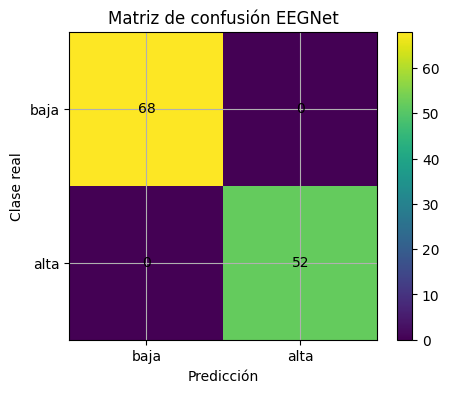


MÉTRICAS POR CLASE

Clase: baja
Sensibilidad (Recall): 1.0000
Especificidad:         1.0000

Clase: alta
Sensibilidad (Recall): 1.0000
Especificidad:         1.0000


In [9]:
X_tr_torch = torch.tensor(X_tr_e, dtype=torch.float32)
X_va_torch = torch.tensor(X_va_e, dtype=torch.float32)

y_tr_torch = torch.tensor(y_tr_e, dtype=torch.long)
y_va_torch = torch.tensor(y_va_e, dtype=torch.long)

train_ds = TensorDataset(X_tr_torch, y_tr_torch)
val_ds = TensorDataset(X_va_torch, y_va_torch)

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)

val_loader = DataLoader(val_ds, batch_size=32, shuffle=False)


class EEGNet(nn.Module):

    def __init__(self, n_classes=2):
        super().__init__()
        F1 = 8
        D = 2
        F2 = 16
        C = 14
        # BLOQUE 1 — temporal conv
        self.block1 = nn.Sequential(
            nn.Conv2d(
                in_channels=1,
                out_channels=F1,
                kernel_size=(1, 64),
                padding=(0, 32),
                bias=False
            ),
            nn.BatchNorm2d(F1)
        )
        # BLOQUE 2 — depthwise spatial
        self.block2 = nn.Sequential(
            nn.Conv2d(
                in_channels=F1,
                out_channels=F1 * D,
                kernel_size=(C, 1),
                groups=F1,
                bias=False
            ),
            nn.BatchNorm2d(F1 * D),
            nn.ELU(),
            nn.AvgPool2d(
                kernel_size=(1, 4)
            ),
            nn.Dropout(0.25)
        )
        # BLOQUE 3 — separable conv
        self.block3 = nn.Sequential(
            # depthwise
            nn.Conv2d(
                in_channels=F1 * D,
                out_channels=F1 * D,
                kernel_size=(1, 16),
                padding=(0, 8),
                groups=F1 * D,
                bias=False
            ),
            # pointwise
            nn.Conv2d(
                in_channels=F1 * D,
                out_channels=F2,
                kernel_size=(1, 1),
                bias=False
            ),
            nn.BatchNorm2d(F2),
            nn.ELU(),
            nn.AvgPool2d(
                kernel_size=(1, 8)
            ),
            nn.Dropout(0.25)
        )

        # Calcular tamaño automáticamente
        with torch.no_grad():
            dummy = torch.zeros(1, 1, 14, 128)
            x = self.block1(dummy)
            x = self.block2(x)
            x = self.block3(x)
            flatten_size = x.numel()
        # HEAD
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(
                flatten_size,
                n_classes
            )
        )

    def forward(self, x):
        # [B, C, T] -> [B, 1, C, T]
        x = x.unsqueeze(1)
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        x = self.classifier(x)
        return x


device = "cuda" if torch.cuda.is_available() else "cpu"
print("Usando:", device)

model = EEGNet().to(device)

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-3
)


n_epochs = 10

train_losses = []
val_accs = []

for epoch in range(n_epochs):
    model.train()
    running_loss = 0
    for x_batch, y_batch in train_loader:
        x_batch = x_batch.to(device)
        y_batch = y_batch.to(device)
        outputs = model(x_batch)
        loss = criterion(outputs, y_batch)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    epoch_loss = running_loss / len(train_loader)
    train_losses.append(epoch_loss)

    model.eval()

    correct = 0
    total = 0

    with torch.no_grad():

        for x_batch, y_batch in val_loader:

            x_batch = x_batch.to(device)
            y_batch = y_batch.to(device)

            outputs = model(x_batch)

            preds = torch.argmax(
                outputs,
                dim=1
            )

            correct += (preds == y_batch).sum().item()

            total += y_batch.size(0)

    val_acc = correct / total
    val_accs.append(val_acc)

    print(
        f"Epoch {epoch+1:02d}/{n_epochs} | "
        f"loss={epoch_loss:.4f} | "
        f"val_acc={val_acc:.4f}"
    )

model.eval()

y_true = []
y_pred = []

with torch.no_grad():

    for x_batch, y_batch in val_loader:

        x_batch = x_batch.to(device)

        outputs = model(x_batch)

        preds = torch.argmax(
            outputs,
            dim=1
        )

        y_true.extend(y_batch.numpy())
        y_pred.extend(preds.cpu().numpy())

y_true = np.array(y_true)
y_pred = np.array(y_pred)


val_acc_final = np.mean(
    y_true == y_pred
)

print("\n" + "="*50)
print(f"VAL_ACC FINAL: {val_acc_final:.4f}")


cm = confusion_matrix(
    y_true,
    y_pred
)

print("\nMATRIZ DE CONFUSIÓN:")
print(cm)

plt.figure(figsize=(5,4))

plt.imshow(cm)

plt.colorbar()

labels = [
    "baja",
    "alta"
]

plt.xticks(
    range(2),
    labels
)

plt.yticks(
    range(2),
    labels
)

plt.xlabel("Predicción")
plt.ylabel("Clase real")
plt.title("Matriz de confusión EEGNet")

for i in range(2):
    for j in range(2):

        plt.text(
            j,
            i,
            cm[i, j],
            ha="center",
            va="center"
        )

plt.show()


print("\nMÉTRICAS POR CLASE")

for i, clase in enumerate(labels):

    TP = cm[i, i]

    FN = cm[i, :].sum() - TP

    FP = cm[:, i].sum() - TP

    TN = cm.sum() - TP - FN - FP

    sensibilidad = TP / (TP + FN)

    especificidad = TN / (TN + FP)

    print(f"\nClase: {clase}")
    print(f"Sensibilidad (Recall): {sensibilidad:.4f}")
    print(f"Especificidad:         {especificidad:.4f}")

### Preguntas conceptuales — EEGNet (Ej 2.1)

Justificá brevemente cada decisión de la arquitectura. Una o dos oraciones por pregunta.

1. La primera conv tiene kernel `(1, 64)`. ¿Por qué solo en el eje temporal (alto 1) y no en el espacial?
2. A `fs=128 Hz`, ¿cuántos segundos cubre un kernel de 64? ¿Por qué tiene sentido ese tamaño para EEG?
3. La segunda conv tiene kernel `(C=14, 1)` (todo el eje de canales) y `groups=F1` (depthwise). ¿Qué aprende esa conv? ¿Por qué es depthwise?
4. ¿Qué representa el **depth multiplier** `D=2`?
5. ¿Por qué `AvgPool2d` en vez de `MaxPool2d`? ¿Y por qué `ELU` en vez de `ReLU`?
6. ¿Qué es una **separable convolution** (depthwise + pointwise)? ¿Por qué se usa en vez de una conv estándar?
7. El pool del bloque 3 es `(1, 8)`, más grande que el del bloque 2 `(1, 4)`. ¿Por qué se vuelve más agresivo al final?
8. ¿Para qué sirve `Dropout(0.25)`?

#### Respuesta

1. La primera conv ve solo el eje temporal porque busca aprender patrones de frecuencia dentro de cada canal por separado, sin mezclar todavía la info de los electrodos.

2. Con fs=128Hz, cada sample 1/128=0.0078s, entonces con kernerl de 64 → 64/128=0.5s. Este tamaño tiene sentido porque las oscilaciones del EEG necesitan varias muestras para ser identificadas, y acá estaríamos observando varios ciclos.

3. Esta conv aprende relaciones espaciales entre los distintos canales (distribución de  patrones entre los electrodos). Se implementa como depthwise para que cada filtro aprendido en la primera capa tenga su combinación espacial, evitando mezclar la información.

4. El parámetro D=2 me dice cuántos filtros espaciales aprende la red para cada filtro temporal de la primera capa, permitiendo capturar una mayor variedad de patrones.

5. Utilizamos AvgPool2d porque en EEG es más importante conservar la información global de la señal y sus oscilaciones que quedarse solo con máximos(como haría MaxPool). Por otro lado, usamos ELU en lugar de ReLU porque mantiene pequeños valores negativos (en vez de poner 0) evitando perder demasiada información.

6. Una separable convolution divide la convolución en una depthwise conv, que extrae patrones de cada canal o feature, y una pointwise conv(1×1), que combina la información entre filtros. Se usa porque reduce la cantidad de parámetros y, por lo tanto, el costo computacional.

7. En las primeras capas se preserva más resolución temporal para no perder info relevante. Para el final, cuando ya se extrajeron las características principales, se puede reducir aún más la dimensión temporal para simplificar y disminuir la cantidad de parámetros antes de la clasificación.

8. Dropout(0.25) desactiva de forma aleatoria el 25% de las neuronas durante el entrenamiento. Esto ayuda a evitar el overfitting, haciendo que la red no dependa demasiado de un conjunto específico de features y generalice mejor a nuevos datos.

## 3. CNN ↔ Transformer — campo receptivo y atención (slides 31–33)

**Lo que el PDF quiere mostrar:** una CNN tiene **campo receptivo finito** (slide 31). Un Transformer mira **toda la secuencia** de una sola pasada (slide 32) usando **self-attention** (slide 33).

Tarea: ventanas de 30 s con dos *spike trains* — uno al segundo 1, otro al segundo 25 — cada uno a 5 Hz o 12 Hz. Preguntamos si matchean. Para responder hay que comparar dos eventos separados **24 segundos** — fuera del campo receptivo de una CNN razonable.

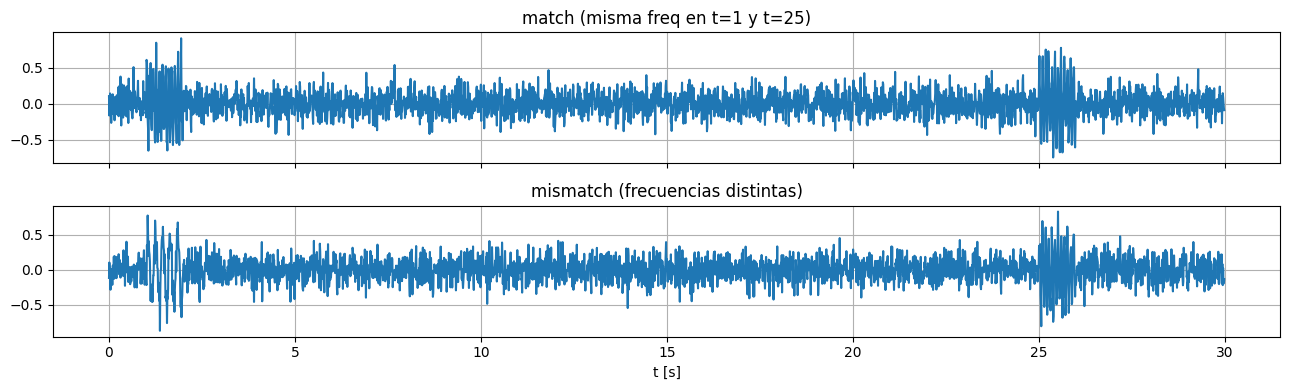

In [11]:
FS_LC = 100; DUR_LC = 30.0; T_LC = int(DUR_LC * FS_LC)

def make_long_context(label, rng):
    t = np.arange(T_LC) / FS_LC
    sig = 0.15 * rng.standard_normal(T_LC).astype(np.float32)
    f1 = rng.choice([5, 12])
    sig[(t >= 1) & (t < 2)] += 0.5 * np.sin(2*np.pi*f1*t[(t >= 1) & (t < 2)])
    f2 = f1 if label == 0 else (12 if f1 == 5 else 5)
    sig[(t >= 25) & (t < 26)] += 0.5 * np.sin(2*np.pi*f2*t[(t >= 25) & (t < 26)])
    return sig.astype(np.float32)

rng = np.random.default_rng(11); n_per = 400
X_lc = np.stack([make_long_context(c, rng) for c in [0]*n_per + [1]*n_per])
y_lc = np.array([0]*n_per + [1]*n_per, dtype=np.int64)
idx = rng.permutation(len(X_lc)); X_lc, y_lc = X_lc[idx], y_lc[idx]
split = int(0.8*len(X_lc))
X_tr_lc, X_va_lc = X_lc[:split], X_lc[split:]
y_tr_lc, y_va_lc = y_lc[:split], y_lc[split:]

fig, axes = plt.subplots(2, 1, figsize=(13, 4), sharex=True)
axes[0].plot(np.arange(T_LC)/FS_LC, X_lc[y_lc == 0][0]); axes[0].set_title('match (misma freq en t=1 y t=25)')
axes[1].plot(np.arange(T_LC)/FS_LC, X_lc[y_lc == 1][0]); axes[1].set_title('mismatch (frecuencias distintas)')
axes[-1].set_xlabel('t [s]')
plt.tight_layout(); plt.show()

### Demo · una CNN no puede resolver esta tarea

Definimos una CNN razonable (3 conv layers con stride=2) y la entrenamos. Su campo receptivo no llega a abarcar los 30 s — queda en *chance level*.

In [12]:
class SmallCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv1d(1, 16, 7, stride=2, padding=3), nn.ReLU(),
            nn.Conv1d(16, 32, 5, stride=2, padding=2), nn.ReLU(),
            nn.Conv1d(32, 32, 5, stride=2, padding=2), nn.ReLU(),
            nn.AdaptiveAvgPool1d(1), nn.Flatten(),
            nn.Linear(32, 2))
    def forward(self, x): return self.net(x)

def train_clf(model, X_tr, y_tr, X_va, y_va, epochs=10, lr=1e-3):
    opt = torch.optim.Adam(model.parameters(), lr=lr); crit = nn.CrossEntropyLoss()
    loader = DataLoader(TensorDataset(torch.from_numpy(X_tr).float(), torch.from_numpy(y_tr)),
                        batch_size=32, shuffle=True)
    for _ in range(epochs):
        model.train()
        for xb, yb in loader:
            loss = crit(model(xb.to(device).unsqueeze(1)), yb.to(device))
            opt.zero_grad(); loss.backward(); opt.step()
    model.eval()
    with torch.no_grad():
        pred = model(torch.from_numpy(X_va).float().to(device).unsqueeze(1)).argmax(1).cpu().numpy()
    return (pred == y_va).mean()

torch.manual_seed(0)
acc_cnn = train_clf(SmallCNN().to(device), X_tr_lc, y_tr_lc, X_va_lc, y_va_lc)
print(f'SmallCNN val_acc = {acc_cnn:.3f}  (chance = 0.50, CNN limitada por campo receptivo)')

SmallCNN val_acc = 0.525  (chance = 0.50, CNN limitada por campo receptivo)


### Ejercicio 3.1 — implementar y entrenar un mini-Transformer 1D (slide 33)

Implementá un Transformer simple que pueda resolver la tarea. La ventaja sobre la CNN es que **self-attention conecta cualquier par de instantes en una sola capa** — sin importar la distancia.

**Arquitectura:**

```
1. Patch embedding
   Conv1D(in=1, out=64, kernel_size=50, stride=50)   # cada patch = 0.5 s
   transpose para quedar [B, N_patches=60, dim=64]

2. Positional embedding (parámetro aprendido)
   nn.Parameter de shape [1, N_patches=60, dim=64], inicializado random pequeño
   Se suma a la salida del patch embedding

3. Bloque de atención (con conexión residual)
   LayerNorm  →  MultiheadAttention(dim=64, num_heads=4, batch_first=True)
   suma residual con la entrada del bloque

4. Bloque feed-forward (con conexión residual)
   LayerNorm  →  Linear(64 → 128)  →  GELU  →  Linear(128 → 64)
   suma residual

5. Clasificador
   promedio sobre patches (mean dim=1)  →  Linear(64 → 2)
```

**Entrenamiento:** 10 epochs, Adam (lr=3e-4), `CrossEntropyLoss`.

Después de entrenar, comparé el `val_acc` con `acc_cnn`. El Transformer debería resolver la tarea (~1.0), mientras que la CNN se queda en chance.

*cambiamos el lr porque sino nos daba peor la acc de el Transformer y no tenía sentido*

In [ ]:

train_ds = TensorDataset(
    torch.from_numpy(X_tr_lc).float(),
    torch.from_numpy(y_tr_lc)
)

val_ds = TensorDataset(
    torch.from_numpy(X_va_lc).float(),
    torch.from_numpy(y_va_lc)
)

train_loader = DataLoader(
    train_ds,
    batch_size=32,
    shuffle=True
)

val_loader = DataLoader(
    val_ds,
    batch_size=32,
    shuffle=False
)


class MiniTransformer1D(nn.Module):

    def __init__(self):
        super().__init__()

        self.dim = 64
        self.n_patches = 60
        # 1. Patch embedding
        self.patch_embed = nn.Conv1d(
            in_channels=1,
            out_channels=64,
            kernel_size=50,
            stride=50
        )
        # 2. Positional embedding
        self.pos_embed = nn.Parameter(
            torch.randn(
                1,
                self.n_patches,
                self.dim
            ) * 0.1
        )
        # 3. Attention block
        self.norm1 = nn.LayerNorm(64)

        self.attn = nn.MultiheadAttention(
            embed_dim=64,
            num_heads=4,
            batch_first=True
        )
        # 4. Feed-forward block
        self.norm2 = nn.LayerNorm(64)

        self.ffn = nn.Sequential(

            nn.Linear(64, 128),

            nn.GELU(),

            nn.Linear(128, 64)
        )
        # 5. Classifier
        self.classifier = nn.Linear(
            64,
            2
        )

    def forward(self, x):

        # [B, T] -> [B, 1, T]
        x = x.unsqueeze(1)
        # Patch embedding [B,1,3000] -> [B,64,60]
        x = self.patch_embed(x)
        # [B,64,60] -> [B,60,64]
        x = x.transpose(1, 2)
        # Positional embedding
        x = x + self.pos_embed
        # Attention block + residual
        x_norm = self.norm1(x)

        attn_out, _ = self.attn(
            x_norm,
            x_norm,
            x_norm
        )

        x = x + attn_out

        # Feed-forward block + residual
        x_norm = self.norm2(x)

        ff_out = self.ffn(x_norm)

        x = x + ff_out

        # Mean pooling over patches
        # [B,60,64] -> [B,64]
        x = x.mean(dim=1)

        # Classification
        x = self.classifier(x)
        return x



device = (
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

print("Usando:", device)

torch.manual_seed(0)

model = MiniTransformer1D().to(device)

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-3
)


n_epochs = 10

for epoch in range(n_epochs):

    model.train()

    running_loss = 0

    for x_batch, y_batch in train_loader:

        x_batch = x_batch.to(device)
        y_batch = y_batch.to(device)

        outputs = model(x_batch)

        loss = criterion(
            outputs,
            y_batch
        )

        optimizer.zero_grad()

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

    epoch_loss = (
        running_loss /
        len(train_loader)
    )

    model.eval()

    correct = 0
    total = 0

    with torch.no_grad():

        for x_batch, y_batch in val_loader:

            x_batch = x_batch.to(device)
            y_batch = y_batch.to(device)

            outputs = model(x_batch)

            preds = torch.argmax(
                outputs,
                dim=1
            )

            correct += (
                preds == y_batch
            ).sum().item()

            total += y_batch.size(0)

    val_acc = correct / total

    print(
        f"Epoch {epoch+1:02d}/{n_epochs} | "
        f"loss={epoch_loss:.4f} | "
        f"val_acc={val_acc:.4f}"
    )


model.eval()

with torch.no_grad():

    pred_tf = model(
        torch.from_numpy(X_va_lc)
        .float()
        .to(device)
    ).argmax(1).cpu().numpy()

acc_transformer = (
    pred_tf == y_va_lc
).mean()

# Comparación CNN vs Transformer
print("\n" + "="*50)
print(f"SmallCNN val_acc      = {acc_cnn:.3f}")
print(f"Transformer val_acc   = {acc_transformer:.3f}")
print("="*50)

Usando: cpu
Epoch 01/10 | loss=0.6929 | val_acc=0.4750
Epoch 02/10 | loss=0.6969 | val_acc=0.4750
Epoch 03/10 | loss=0.6871 | val_acc=0.4938
Epoch 04/10 | loss=0.5507 | val_acc=0.9500
Epoch 05/10 | loss=0.0252 | val_acc=1.0000
Epoch 06/10 | loss=0.0001 | val_acc=1.0000
Epoch 07/10 | loss=0.0000 | val_acc=1.0000
Epoch 08/10 | loss=0.0000 | val_acc=1.0000
Epoch 09/10 | loss=0.0000 | val_acc=1.0000
Epoch 10/10 | loss=0.0000 | val_acc=1.0000

SmallCNN val_acc      = 0.525
Transformer val_acc   = 1.000


### Preguntas conceptuales — mini-Transformer (Ej 3.1)

Justificá brevemente cada decisión de la arquitectura. Una o dos oraciones por pregunta.

1. El **patch embedding** es una `Conv1D(kernel=50, stride=50)`. ¿Para qué partir la señal en patches? ¿Qué pasaría si pusiéramos todo el tensor directamente en la atención?
2. ¿Cuántos segundos cubre cada patch (a `fs=100 Hz`) y cuántos patches totales hay en una ventana de 30 s?
3. ¿Para qué hace falta el **positional embedding**? ¿Qué pasaría sin él en una tarea como esta (match/mismatch)?
4. En `MultiheadAttention(dim=64, num_heads=4)`: ¿qué representa cada **cabeza** y por qué se usan varias en paralelo?
5. ¿Por qué hay **conexiones residuales** (`e = e + attn_out`)? ¿Qué problema previenen?
6. ¿Para qué sirve el **bloque feed-forward** después de la atención si ya hicimos atención? ¿Por qué la dimensión interna es `2 × EMBED`?
7. ¿Por qué `LayerNorm` y no `BatchNorm` (como sí usamos en EEGNet)?
8. ¿Por qué hacemos `e.mean(dim=1)` al final antes del clasificador?

#### Respuesta

1. Dividimos la señal en patches para reducir la longitud de la secuencia y que sea viable computacionalmente. Si usaramos las 3000 muestras en MultiheadAttention, el costo sería mucho mayor porque la atención compara todos los instantes entre sí.

2. Como fs=100Hz, cada sample 1/100=0.01s, entonces un patch de 50 muestras cubre 0.5s. Como la señal total dura 30s → 30/0.5=60 patches.

3. El positional embedding le da info temporal al Transformer sobre en qué parte de la secuencia ocurre cada evento. Sin él, el modelo vería los patches como un conjunto sin orden, por lo que le costaría distinguir si un patrón ocurrió cerca del segundo 1 o del segundo 25.

4. Cada head de atención puede enfocarse en distintos aspectos de la señal o distintas relaciones entre patches (frecuencia, contexto, regiones específicas, etc) permitiendo que el modelo aprenda múltiples relaciones en simultáneo. 

5. e representa info original de la secuencia y attn_out, info nueva aprendida por la self-attention al relacionar distintos patches. La conexión residual nos permite conservar la información original mientras se agrega el contexto aprendido, evitando pérdida de información y vanishing gradients.

6. La atención sirve para relacionar distintos patches de la secuencia, pero el bloque feed-forward permite procesar e interpretar esa información ya conectada. La dimensión 2 × EMBED le da más capacidad al modelo para aprender relaciones complejas antes de volver al tamaño original.

7. LayerNorm normaliza cada ejemplo de forma individual y no depende de las estadísticas del batch, lo que mejora el entrenamiento en Transformers. En cambio, BatchNorm usa información de todo el batch y suele funcionar mejor en CNNs.

8. Promediamos todos los patches para obtener una representación global de toda la secuencia antes de clasificar. Esto nos permite que el clasificador tome una decisión basada en toda la info temporal de la ventana de 30s y no solo en un instante.


## Cierre — takeaways de la clase

1. **Una señal 1D = lista de números + `fs`.** ECG, EEG y PPG son instancias del mismo concepto.
2. **El filtro deslizante es el throughline.** Pan-Tompkins → Conv1D → self-attention — lo que cambia es **cuántos parámetros**    y **cuánto contexto** ve cada operación.
3. **AI extiende al clásico, no lo reemplaza.** Pan-Tompkins de 1985 sigue siendo baseline en producción.
4. **Dimensionalidad escala el problema.** ECG (1D) → PPG (1D + movimiento) → EEG (2D = canales × tiempo). El framework es el mismo;    la arquitectura se adapta.
5. **Las CNNs tienen campo receptivo finito.** Cuando la tarea requiere contexto largo, hay que ir a Transformers.